In [1]:
import os
import zipfile
import pandas as pd
import numpy as np
import keras
from keras import layers, ops, applications
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf
import matplotlib.cm as cm

In [2]:
# Unziping Dataset
if not os.path.exists('steel_data'):
    with zipfile.ZipFile('IMAGES.zip', 'r') as zip_ref:
        zip_ref.extractall('steel_data')

data = []
image_dir = 'steel_data/IMAGES' 
for file in os.listdir(image_dir):
    if file.lower().endswith(('.png', '.jpg', '.jpeg')):
        # Split 'crazing_1.jpg' by '_' to get 'crazing'
        label_name = file.split('_')[0].capitalize()
        data.append({
            'filepath': os.path.join(image_dir, file),
            'label_name': label_name
        })

df = pd.DataFrame(data)
class_names = sorted(df['label_name'].unique())
class_map = {name: i for i, name in enumerate(class_names)}
df['label'] = df['label_name'].map(class_map)

print(f"Detected Classes: {class_names}")
print(df['label_name'].value_counts())

# Load Images into Arrays
def get_data_arrays(dataframe):
    images, labels = [], []
    for _, row in dataframe.iterrows():
        img = Image.open(row['filepath']).convert('L').resize((200, 200))
        images.append(np.array(img))
        labels.append(row['label'])
    return np.array(images).astype("float32").reshape(-1, 200, 200, 1), np.array(labels)

# 70/15/15 Split
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)

x_train, y_train = get_data_arrays(train_df)
x_val, y_val = get_data_arrays(val_df)
x_test, y_test = get_data_arrays(test_df)

Detected Classes: ['Crazing', 'Inclusion', 'Patches', 'Pitted', 'Rolled-in', 'Scratches']
label_name
Crazing      300
Inclusion    300
Patches      300
Pitted       300
Rolled-in    300
Scratches    300
Name: count, dtype: int64


In [3]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"), 
    
    layers.RandomRotation(0.02), 
    
    layers.RandomTranslation(height_factor=0.05, width_factor=0.05),
], name="augmentation")

model = keras.Sequential([
    layers.Input(shape=(200, 200, 1)),
    layers.Rescaling(1./255),
    
    data_augmentation,

    # Layer 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Layer 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Layer 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(), 
    layers.MaxPooling2D((2, 2)),

    # Global Average Pooling 
    layers.GlobalAveragePooling2D(),
    
    
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3), 
    
    layers.Dense(len(class_names), activation='softmax')
])

optimizer = keras.optimizers.Adam(learning_rate=0.001)

model.compile(optimizer=optimizer, 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 200, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 100, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 50, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,854 (433.02 KB)

 Trainable params: 110,406 (431.27 KB)

 Non-trainable params: 448 (1.75 KB)

In [4]:
history = model.fit(
    x_train, y_train, 
    validation_data=(x_val, y_val), 
    epochs=20, 
    batch_size=32
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 33s 756ms/step - accuracy: 0.5279 - loss: 1.2627 - val_accuracy: 0.2889 - val_loss: 1.8671
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 31s 780ms/step - accuracy: 0.7543 - loss: 0.6295 - val_accuracy: 0.1667 - val_loss: 2.2028
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 30s 757ms/step - accuracy: 0.8264 - loss: 0.5058 - val_accuracy: 0.3111 - val_loss: 2.9353
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 31s 779ms/step - accuracy: 0.8530 - loss: 0.4244 - val_accuracy: 0.1667 - val_loss: 3.3263
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 30s 761ms/step - accuracy: 0.8726 - loss: 0.3526 - val_accuracy: 0.1667 - val_loss: 3.8350
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 31s 766ms/step - accuracy: 0.9112 - loss: 0.2599 - val_accuracy: 0.1667 - val_loss: 4.4703
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 30s 761ms/step - accuracy: 0.9138 - loss: 0.2347 - val_accuracy: 0.1667 - val_loss: 4.9268
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 30s 763ms/step - accuracy: 0.9247 - loss: 0.2271 - val_accu

In [5]:
# Transfer Learning Model (MobileNetV2)
base_model = keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(200, 200, 3))
base_model.trainable = False

transfer_model = keras.Sequential([
    keras.layers.Input(shape=(200, 200, 1)),
    keras.layers.Lambda(lambda x: keras.ops.repeat(x, 3, axis=-1)),
    keras.layers.Rescaling(scale=1./127.5, offset=-1.),      # MobileNet normalization
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(len(class_names), activation='softmax')
])

transfer_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
transfer_model.build((None, 200, 200, 1))

print("\nTraining Transfer Learning Model...")
history_tl = transfer_model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=15, batch_size=32)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_15384\2648519036.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(200, 200, 3))




Training Transfer Learning Model...
Epoch 1/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 411ms/step - accuracy: 0.6878 - loss: 1.0162 - val_accuracy: 0.9926 - val_loss: 0.1424
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 18s 338ms/step - accuracy: 0.9871 - loss: 0.1198 - val_accuracy: 0.9889 - val_loss: 0.0772
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 367ms/step - accuracy: 0.9959 - loss: 0.0634 - val_accuracy: 0.9889 - val_loss: 0.0546
Epoch 4/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 368ms/step - accuracy: 0.9977 - loss: 0.0496 - val_accuracy: 0.9889 - val_loss: 0.0446
Epoch 5/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 17s 423ms/step - accuracy: 0.9990 - loss: 0.0337 - val_accuracy: 0.9926 - val_loss: 0.0361
Epoch 6/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 373ms/step - accuracy: 0.9958 - loss: 0.0287 - val_accuracy: 0.9889 - val_loss: 0.0328
Epoch 7/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 224ms/step - accuracy: 1.0000 - loss: 0.0235 - val_accuracy: 0.9889 - val_loss: 0.0314
Epoch 8/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 225ms/step - accura

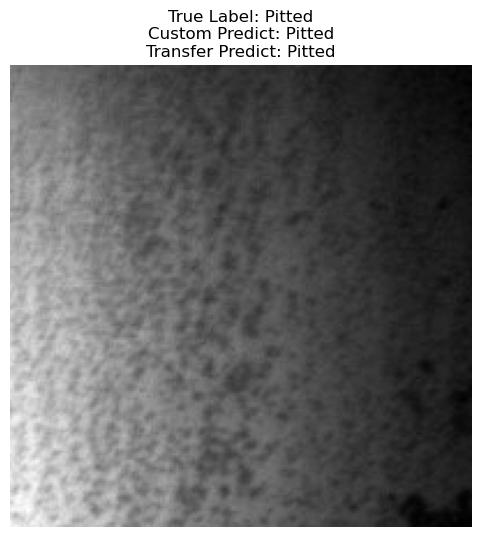

Final Results -> Custom: 47.41% | Transfer: 99.63%


In [6]:
idx = np.random.randint(0, len(x_test))
img_batch = np.expand_dims(x_test[idx], axis=0)

# Preds
p_custom = np.argmax(model.predict(img_batch, verbose=0))
p_tl = np.argmax(transfer_model.predict(img_batch, verbose=0))

plt.figure(figsize=(6, 6))
plt.imshow(x_test[idx].reshape(200, 200), cmap='gray')
plt.title(f"True Label: {class_names[y_test[idx]]}\n"
          f"Custom Predict: {class_names[p_custom]}\n"
          f"Transfer Predict: {class_names[p_tl]}")
plt.axis('off')
plt.show()

# Final Evaluation
c_acc = model.evaluate(x_test, y_test, verbose=0)[1]
t_acc = transfer_model.evaluate(x_test, y_test, verbose=0)[1]
print(f"Final Results -> Custom: {c_acc*100:.2f}% | Transfer: {t_acc*100:.2f}%")

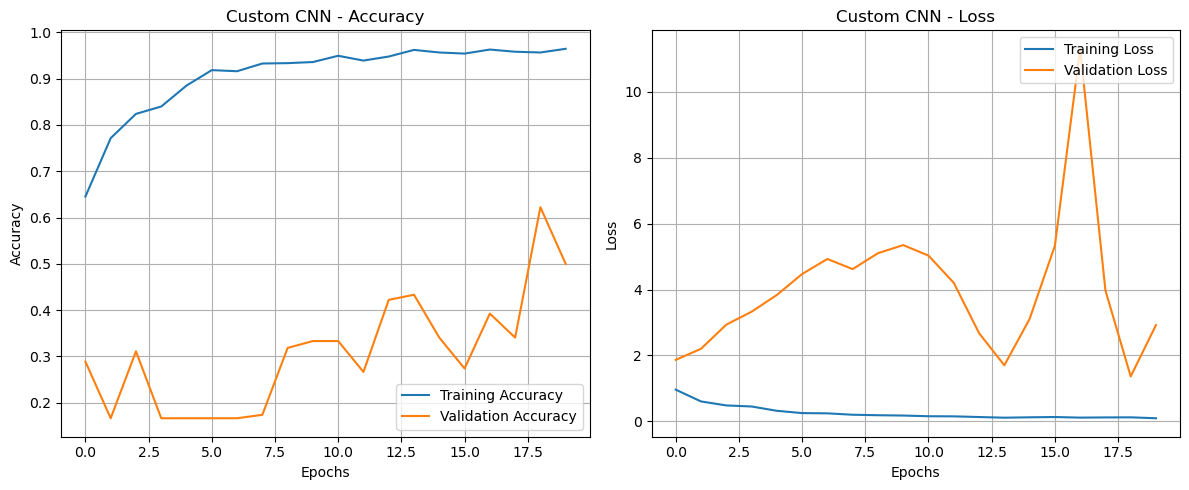

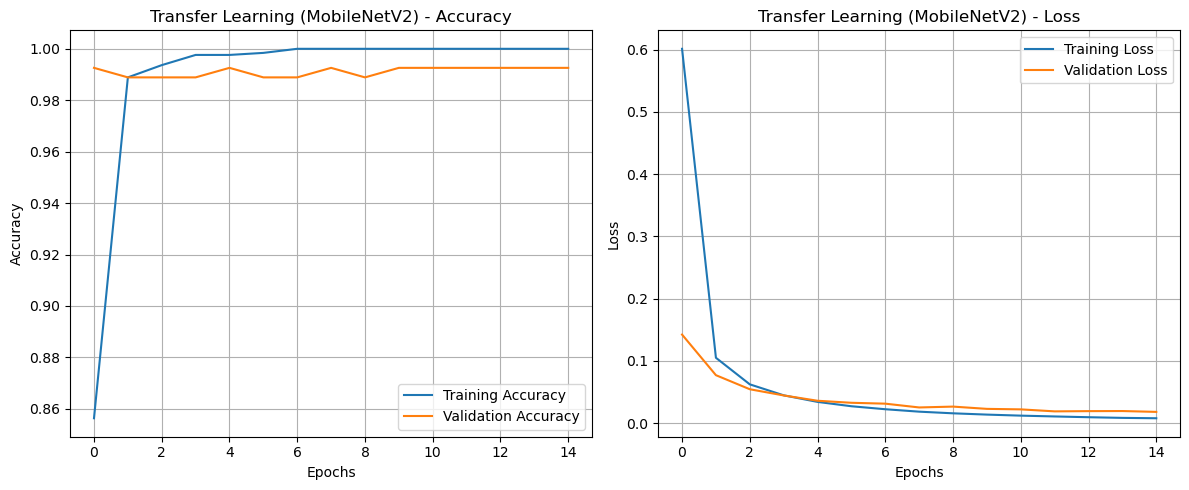

In [7]:
def plot_history(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Plot for Custom CNN
plot_history(history, "Custom CNN")

# Plot for Transfer Learning
plot_history(history_tl, "Transfer Learning (MobileNetV2)")

# Grad-CAM For Custom Model

C:\Users\ASUS\AppData\Local\Temp\ipykernel_15384\3894850973.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


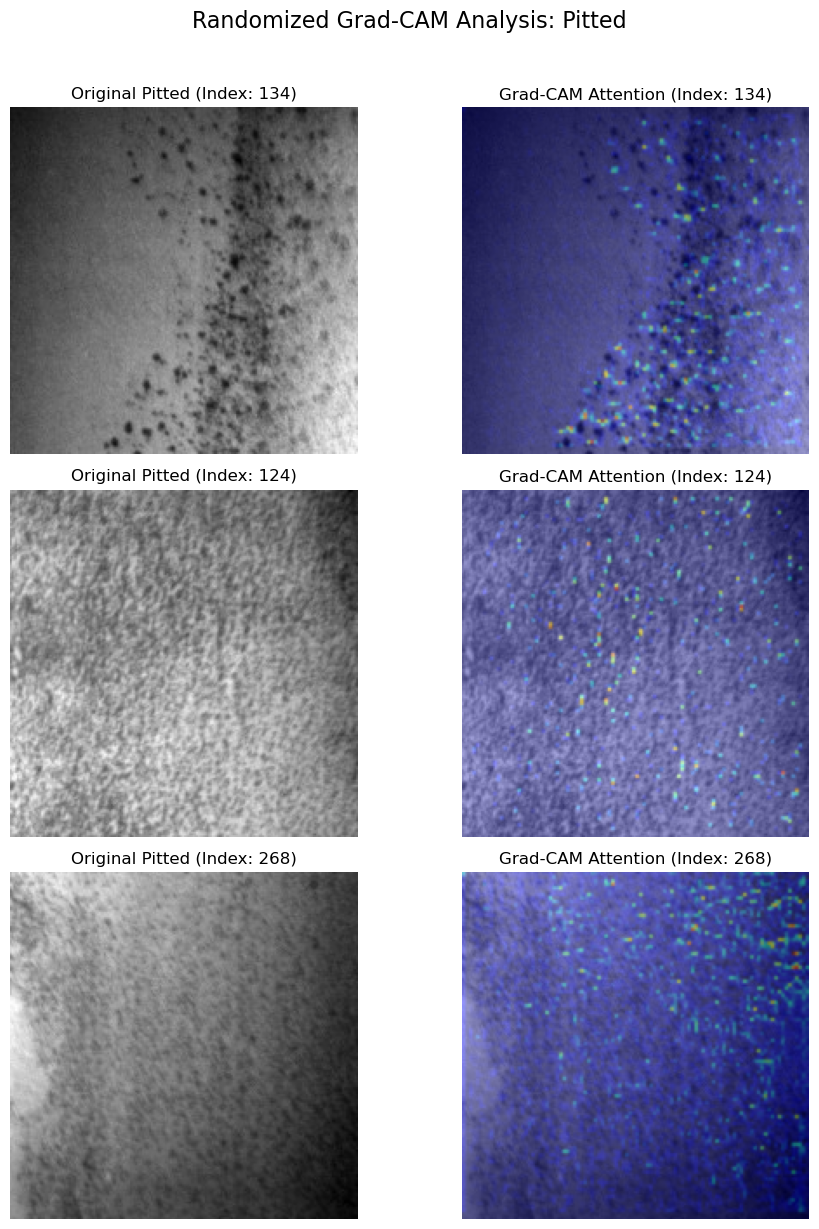

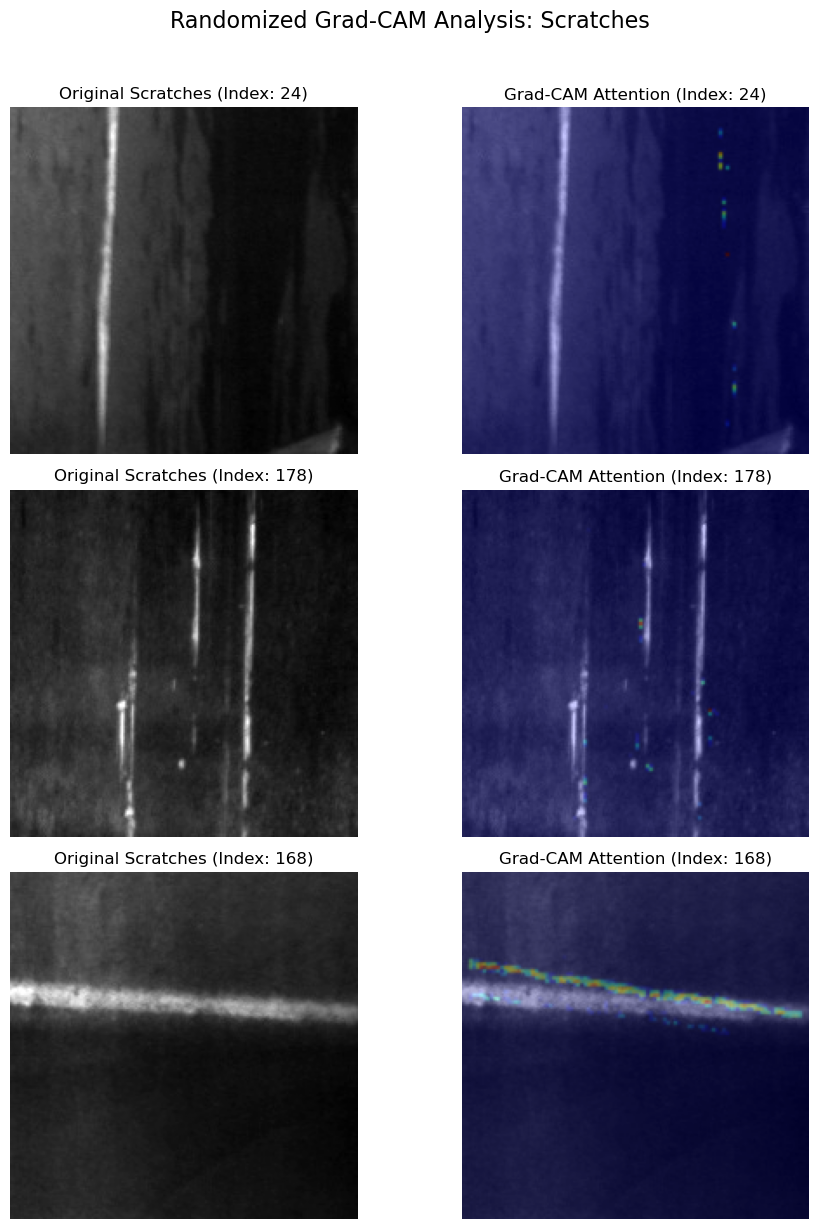

In [ ]:
# HEATMAP GENERATOR FUNCTION
def get_gradcam_heatmap(img_array, model, last_conv_layer_name):
    layer_names = [layer.name for layer in model.layers]
    last_conv_idx = layer_names.index(last_conv_layer_name)
    
    feature_extractor = keras.Sequential(model.layers[:last_conv_idx + 1])
    classifier_layers = model.layers[last_conv_idx + 1:]
    
    with tf.GradientTape() as tape:
        last_conv_layer_output = feature_extractor(img_array)
        tape.watch(last_conv_layer_output)
        
        preds = last_conv_layer_output
        for layer in classifier_layers:
            preds = layer(preds)
            
        top_class_channel = preds[:, ops.argmax(preds[0])]

    grads = tape.gradient(top_class_channel, last_conv_layer_output)
    pooled_grads = ops.mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., None]
    heatmap = ops.squeeze(heatmap)

    # ReLU and Normalize for high contrast
    heatmap = ops.maximum(heatmap, 0) / ops.maximum(ops.max(heatmap), 1e-10)
    return heatmap.numpy()

# OVERLAY GENERATOR FUNCTION
def display_gradcam(img, heatmap, alpha=0.4):
    if np.max(img) <= 1.0:
        img = np.uint8(255 * img)
    
    heatmap = np.uint8(255 * heatmap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.utils.img_to_array(jet_heatmap)

    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = keras.utils.array_to_img(superimposed_img)
    return superimposed_img

def visualize_class_gradcam(target_class_name, num_samples=3):
    last_conv_name = [l.name for l in model.layers if "conv2d" in l.name][-2]
    class_idx = class_map[target_class_name]
    
    all_class_indices = np.where(y_test == class_idx)[0]
    random_indices = np.random.choice(all_class_indices, size=num_samples, replace=False)
    
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))
    plt.suptitle(f"Randomized Grad-CAM Analysis: {target_class_name}", fontsize=16, y=1.02)

    for i, idx in enumerate(random_indices):
        img_sample = x_test[idx:idx+1]
        
        _ = model(img_sample)
        
        heatmap = get_gradcam_heatmap(img_sample, model, last_conv_name)
        overlay = display_gradcam(img_sample[0].reshape(200, 200, 1), heatmap)
        
        # Plot Original Grayscale Image
        axes[i, 0].imshow(img_sample[0].reshape(200, 200), cmap='gray')
        axes[i, 0].set_title(f"Original {target_class_name} (Index: {idx})")
        axes[i, 0].axis('off')
        
        # Plot Grad-CAM Attention Map
        axes[i, 1].imshow(overlay)
        axes[i, 1].set_title(f"Grad-CAM Attention (Index: {idx})")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

visualize_class_gradcam("Pitted", num_samples=3)
visualize_class_gradcam("Scratches", num_samples=3)

# Q1

Changing to a 7×7 filter improves the detection of long-range geometric structures like scratches by increasing the receptive field. However, it increases computational cost and may sacrifice the ability to detect very fine surface textures compared to a deeper stack of smaller filters.

# Q2

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step


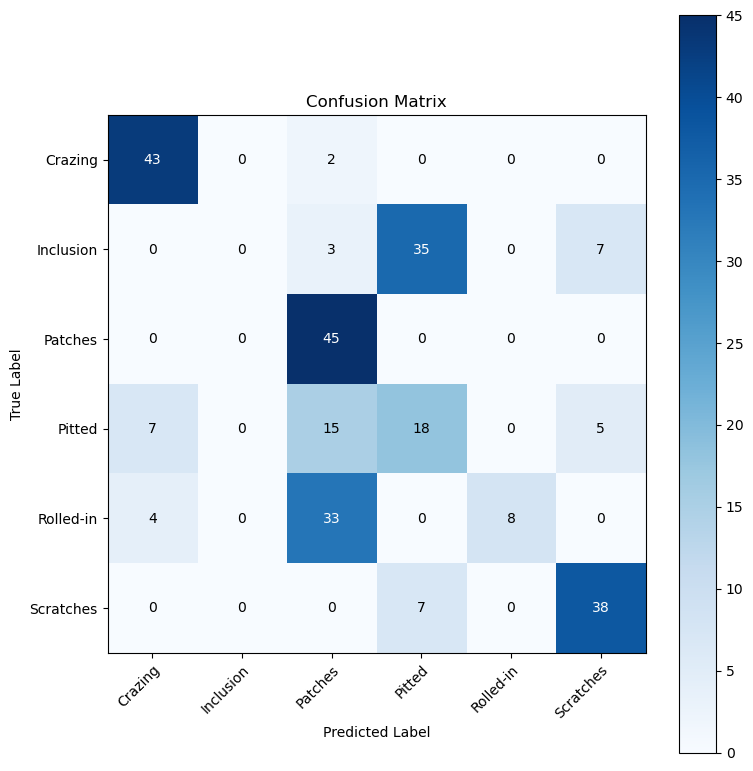

              precision    recall  f1-score   support

     Crazing       0.80      0.96      0.87        45
   Inclusion       0.00      0.00      0.00        45
     Patches       0.46      1.00      0.63        45
      Pitted       0.30      0.40      0.34        45
   Rolled-in       1.00      0.18      0.30        45
   Scratches       0.76      0.84      0.80        45

    accuracy                           0.56       270
   macro avg       0.55      0.56      0.49       270
weighted avg       0.55      0.56      0.49       270



c:\Users\ASUS\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

y_pred_probs = model.predict(x_test) 
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=class_names, yticklabels=class_names,
       title='Confusion Matrix',
       ylabel='True Label',
       xlabel='Predicted Label')

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2. else "black")

fig.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_classes, target_names=class_names))

Most Confused Pair: The model most frequently confuses Rolled-in scale with Patches. Specifically, 33 samples of Rolled-in scale were incorrectly predicted as Patches.

# Visual and Physical Reasoning

From a visual standpoint, these errors occur because the defects share similar grayscale characteristics and spatial textures:

Rolled-in vs. Patches: Both defects often appear as large, irregular, dark gray areas on the steel surface. In a 200×200 grayscale image, the CNN struggles to distinguish between the "smudged" texture of a patch and the "pressed-in" texture of rolled-in scale because their global intensity profiles are nearly identical.

Inclusion vs. Pitted: Both consist of small, dark, localized spots. In your Grad-CAM results, the "Attention" for Pitted images (as seen in your uploaded "Pitted" analysis image) often covers wide regions rather than focusing on individual tiny dots. This suggests the model is looking for "groups of dark spots," which is exactly how Inclusion often appears, leading to the high confusion rate.

Inclusion Failure: The model has 0.00 recall for Inclusions, meaning it failed to correctly identify even a single Inclusion sample. It categorized almost all of them (35/45) as Pitted.

# Q3 Computational Optimization: Pooling Layers

How the Pooling Layer reduces computational cost:

Dimensionality Reduction: The pooling layer performs a downsampling operation that reduces the spatial dimensions (width and height) of the input volume.

Parameter Reduction: By decreasing the number of pixels passed to the next layer, the pooling layer significantly reduces the number of parameters and the total volume of computation (FLOPs) required, making the model faster and less prone to overfitting.

Difference between Max Pooling and Average Pooling in Metallurgical Extraction:

Max Pooling: This method selects the maximum value in a window. In metallurgy, this is superior for identifying sharp defects (like the dark pixels of a scratch or a pit) because it preserves the most prominent and "extreme" features against a lighter background.

Average Pooling: This method calculates the mean of all pixels in a window. It acts as a smoothing filter and is more useful for identifying broader surface trends or general grain textures rather than specific localized defects.